In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
total_revenue = df["TotalAmount"].sum()

print(f"Total Revenue = ₹{total_revenue:,.2f}")

Total Revenue = ₹8,887,208.89


# Revenue Analysis

### Business Insight

The online retail business generated a total revenue of **₹8,887,208.89** during the available transaction period.

This indicates a strong customer base with significant purchasing activity.

From a business perspective:

- High revenue indicates healthy sales performance.
- Revenue should be monitored over time to identify seasonal trends.
- Marketing campaigns can be evaluated by comparing revenue before and after promotions.

In [4]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

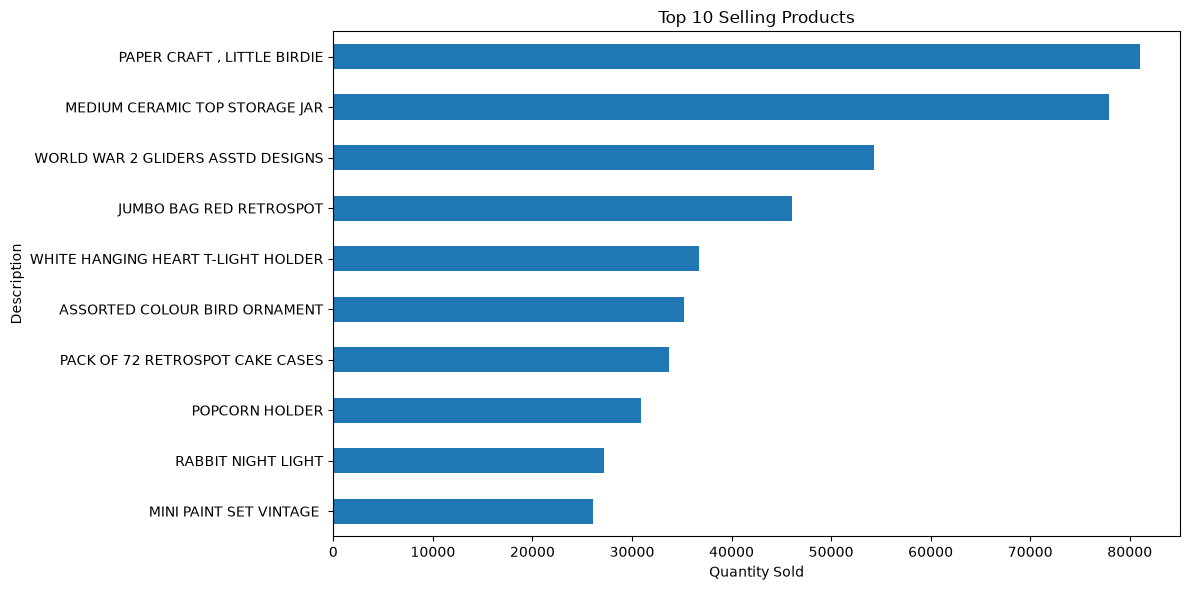

In [5]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Selling Products")

plt.xlabel("Quantity Sold")

plt.tight_layout()

plt.show()

# Top Selling Products

### Business Insight

The top-selling products contribute a large share of total sales.

Business Recommendation:

- Ensure these products remain in stock.
- Promote complementary products together.
- Use these products in recommendation systems.
- Feature these products on the homepage to increase conversions.

In [6]:
country_sales = (
    df.groupby("Country")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

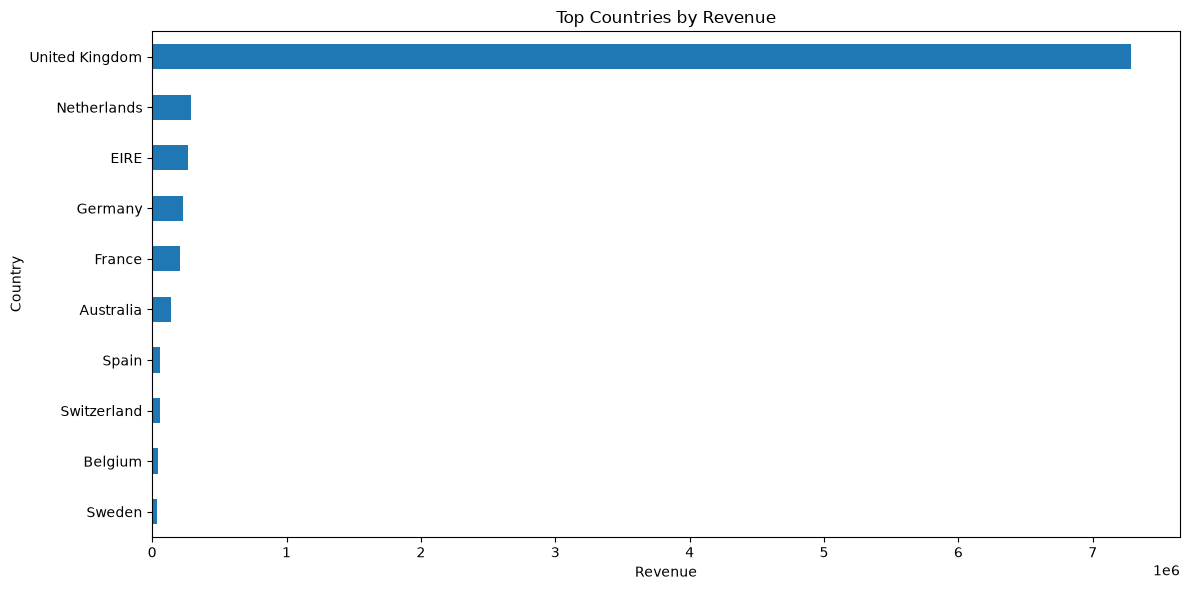

In [7]:
plt.figure(figsize=(12,6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top Countries by Revenue")

plt.xlabel("Revenue")

plt.tight_layout()

plt.show()

# Country-wise Sales

### Business Insight

Revenue is concentrated in a few countries.

Business Recommendation:

- Focus marketing efforts on the highest-performing countries.
- Identify opportunities to expand sales in lower-performing regions.
- Optimize logistics and inventory for countries with high demand.

In [8]:
top_customers = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalAmount, dtype: float64

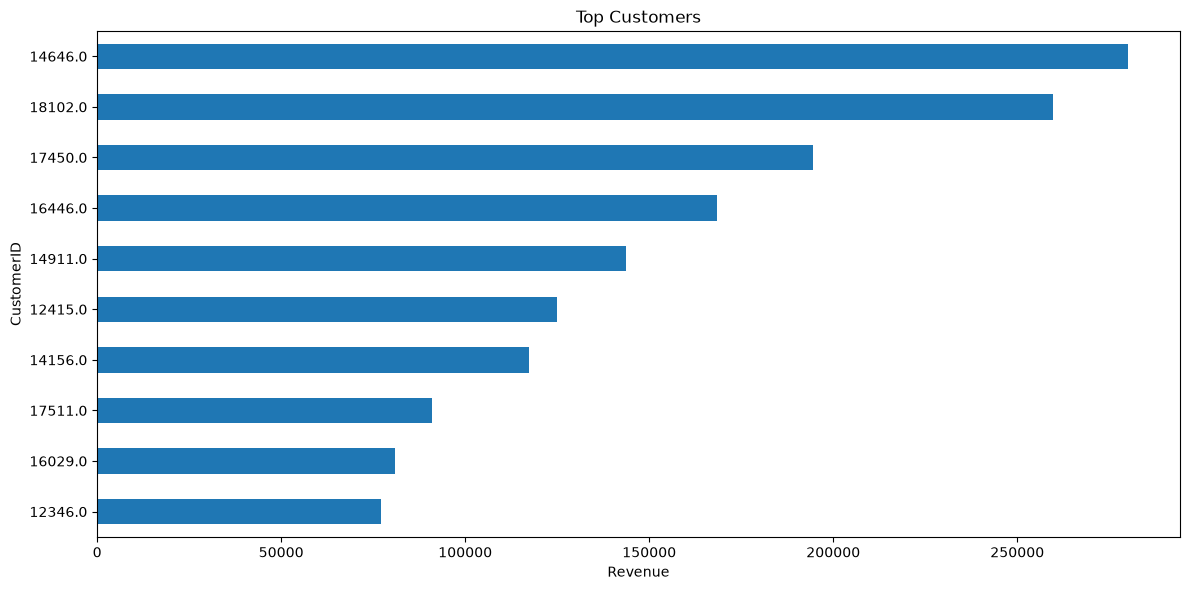

In [9]:
plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top Customers")

plt.xlabel("Revenue")

plt.tight_layout()

plt.show()

# Top Customers

### Business Insight

A small percentage of customers generate a significant portion of total revenue.

Business Recommendation:

- Launch loyalty programs for these customers.
- Provide personalized offers.
- Retain high-value customers through exclusive benefits.

In [10]:
monthly_sales = (
    df.set_index("InvoiceDate")
      .resample("ME")["TotalAmount"]
      .sum()
)

monthly_sales

InvoiceDate
2022-12-31     570422.730
2023-01-31     568101.310
2023-02-28     446084.920
2023-03-31     594081.760
2023-04-30     468374.331
2023-05-31     677355.150
2023-06-30     660046.050
2023-07-31     598962.901
2023-08-31     644051.040
2023-09-30     950690.202
2023-10-31    1035642.450
2023-11-30    1156205.610
2023-12-31     517190.440
Freq: ME, Name: TotalAmount, dtype: float64

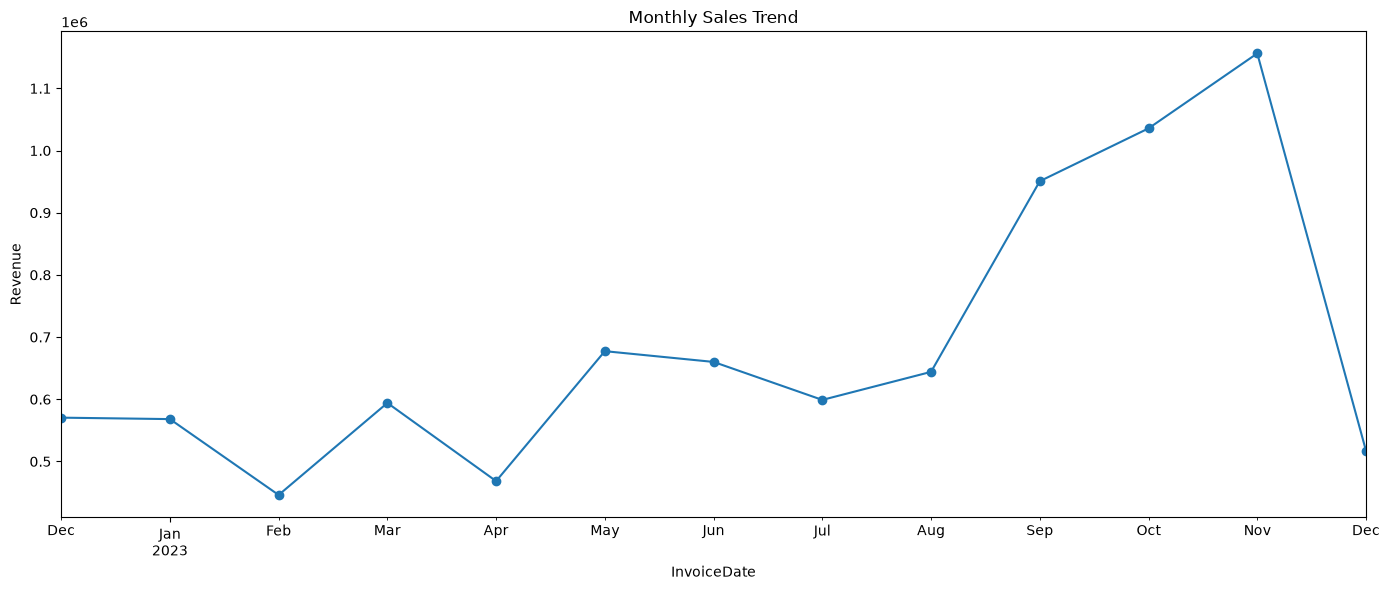

In [11]:
plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

# Monthly Sales Trend

### Business Insight

The monthly trend highlights fluctuations in customer purchases over time.

Business Recommendation:

- Plan inventory according to seasonal demand.
- Schedule promotional campaigns during lower-sales months.
- Use historical trends for future sales forecasting.